##### Imbalance Dataset Logistic Regression ########


In [2]:
from collections import Counter
from sklearn.datasets import make_classification

In [3]:
# imbalanced dataset
from sklearn.datasets import make_classification
import pandas as pd

X, y = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    n_classes=3,
    n_clusters_per_class=1,
    weights=[0.75, 0.20, 0.05],  # imbalance here
    random_state=42
)

df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(6)])
df['target'] = y

print(df['target'].value_counts())

target
0    744
1    201
2     55
Name: count, dtype: int64


In [12]:
Counter(y)

# train an test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

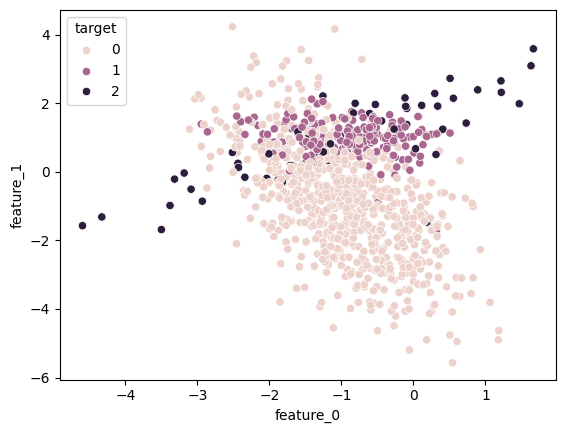

In [6]:
sns.scatterplot(data=df, x='feature_0', y='feature_1', hue='target')
plt.show()

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = [

    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2', None],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [500, 1000],
        'class_weight': ['balanced', None]
    },

    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [500, 1000],
        'class_weight': ['balanced', None]
    },

    {
        'solver': ['saga'],
        'penalty': ['l1', 'l2', 'elasticnet'],
        'C': [0.01, 0.1, 1, 10],
        'max_iter': [500, 1000],
        'l1_ratio': [0.5],
        'class_weight': ['balanced', None]
    }
]
grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)


Best parameters: {'C': 0.01, 'class_weight': None, 'max_iter': 500, 'penalty': None, 'solver': 'newton-cg'}
Best score: 0.6722507550926453


c:\Users\dpk41\OneDrive\Docs\Udemy Python\LinearRegression\PyProjects\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
160 fits failed out of a total of 880.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
160 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\dpk41\OneDrive\Docs\Udemy Python\LinearRegression\PyProjects\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\dpk41\OneDrive\Docs\Udemy Python\LinearRegression\PyProjects\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^

In [15]:
grid_search.best_params_

{'C': 0.01,
 'class_weight': None,
 'max_iter': 500,
 'penalty': None,
 'solver': 'newton-cg'}

In [18]:
y_pred = grid_search.predict(X_test)
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, classification_report, roc_auc_score

print(f1_score(y_test, y_pred, average='macro'))
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.6365596537133199
0.825
[[131   7   0]
 [ 15  31   2]
 [  8   3   3]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90       138
           1       0.76      0.65      0.70        48
           2       0.60      0.21      0.32        14

    accuracy                           0.82       200
   macro avg       0.74      0.60      0.64       200
weighted avg       0.81      0.82      0.81       200

